<a href="https://colab.research.google.com/github/Hniii/Machine-learning/blob/main/Part_0_Q_Learning_with_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 0 : Q-Learning with Neural Networks

# Q-Network Learning

## Introduction

Ce notebook contient un code Python qui implémente l'algorithme de Q-learning avec un réseau neuronal pour entraîner un agent à naviguer dans l'environnement "FrozenLake-v1" de OpenAI Gym. L'objectif de l'agent est d'apprendre à atteindre la case "G" (but) en partant de la case "S" (départ), en évitant de tomber dans les cases "H" (trous) sur un lac gelé représenté par des cases "F" (surface gelée sûre). Au lieu d'utiliser une table Q comme dans l'exemple précédent, ce code utilise un réseau neuronal pour estimer les valeurs Q. L'agent apprendra une stratégie optimale pour maximiser ses chances d'atteindre le but en utilisant un réseau neuronal pour approximer la fonction Q.

In [ ]:
import gym # Importation de la bibliothèque Gym (OpenAI Gym) qui fournit des environnements pour l'apprentissage par renforcement
import numpy as np # Importation la bibliothèque Numpy et la renomme 'np'.Elle est utile pour les calculs numériques
import random # Importation de la bibliothèque 'random' pour générer des nombres aléatoires, utile pour l'exploration.
import tensorflow as tf # Importation de la bibliothèque TensorFlow.TensorFlow est une bibliothèque pour le machine learning, en particulier les réseaux neuronaux.
import matplotlib.pyplot as plt # Importation de la bibliothèque 'matplotlib.pyplot'. Matplotlib sert à créer des graphiques.
%matplotlib inline
tf.compat.v1.disable_eager_execution() # Désactive l'exécution "eager" de TensorFlow 2.x pour utiliser le comportement de TensorFlow 1.x

### Load the environment

## Concepts Clés

Pour comprendre ce code, il est important de connaître quelques concepts de base de l'apprentissage par renforcement :

**Agent** : C'est l'entité qui apprend à prendre des décisions.

**Environnement** : C'est le monde virtuel dans lequel l'agent interagit et apprend (ici, le jeu "FrozenLake-v1").

**État (State)**: C'est une représentation de la situation actuelle de l'agent dans l'environnement (ici, la case où se trouve l'agent dans FrozenLake).

**Action** : C'est une action que l'agent peut réaliser dans l'environnement (ici, se déplacer vers le haut, le bas, la gauche ou la droite dans FrozenLake).

**Récompense (Reward)** : C'est un signal que l'environnement envoie à l'agent pour indiquer si son action était "bonne" ou "mauvaise" (ici, récompense de 1 quand l'agent atteint le but "G", 0 sinon).

**Q-Learning**: C'est un algorithme d'apprentissage par renforcement qui permet à l'agent d'apprendre une "Q-table" qui estime la "qualité" (valeur Q) de chaque action dans chaque état.

**Réseau Neuronal** : C'est un modèle mathématique , inspiré du fonctionnement du cerveau humain, qui est capable d'apprendre des relations complexes entre des entrées (ici, l'état du jeu) et des sorties (ici, les valeurs Q des actions). Dans ce code, on utilise un réseau neuronal pour approximer la Q-table. C'est-à-dire que le réseau neuronal va apprendre à prédire les valeurs Q des actions pour chaque état, sans avoir besoin de stocker toutes ces valeurs dans un tableau (Q-table). Le réseau neuronal est plus puissant et plus compact qu'une table Q, et il peut être utilisé dans des environnements avec un grand nombre d'états, où une table Q deviendrait trop grande.


In [ ]:
env = gym.make('FrozenLake-v1', new_step_api=True) #Création de l'environnement "FrozenLake-v1" de Gym, qui simule le jeu du lac gelé

## The Q-Network Approach

### Implementing the network itself

In [ ]:
tf.compat.v1.reset_default_graph() # Réinitialise le graphe de calcul TensorFlow par défaut.

In [ ]:
inputs1 = tf.compat.v1.placeholder(shape=[1,16], dtype=tf.float32) # Variable TensorFlow qui recevra les données d'entrée (l'état) lors de l'exécution, c'est un tableau 2D avec 1 ligne et 16 colonnes (représentant un état de FrozenLake)
W = tf.Variable(tf.compat.v1.random_uniform([16, 4], minval=0, maxval=0.01)) # Définit une variable TensorFlow 'W' pour les poids (weights) de la première couche du réseau. Ce sont les paramètres du réseau neuronal qu'on va ajuster pendant l'apprentissage pour que le réseau apprenne à faire de bonnes prédictions
Qout = tf.matmul(inputs1,W) # Multiplication matricielle entre l'entrée 'inputs1' et les poids 'W' pour calculer la sortie de la première couche
predict = tf.argmax(Qout,1) # # Détermine l'action prédite par le réseau comme étant celle qui a la plus grande valeur Q dans 'Qout'.
nextQ = tf.compat.v1.placeholder(shape=[1,4], dtype=tf.float32) # Variable TensorFlow  qui sera utiliser pour recevoir les valeurs Q idéales pour l'entraînement
loss = tf.reduce_sum(tf.square(nextQ - Qout)) # Calcule la fonction de perte (erreur quadratique) entre les valeurs Q cibles (nextQ) et les valeurs Q prédites par le réseau (Qout).
trainer = tf.compat.v1.train.GradientDescentOptimizer(learning_rate=0.1) # Définit l'optimiseur "Descente de Gradient" avec un taux d'apprentissage de 0.1.
updateModel = trainer.minimize(loss) # Crée l'opération pour minimiser la perte et mettre à jour le modèle.

###Training the network

In [ ]:
tf.compat.v1.disable_eager_execution() # Désactive l'exécution "eager" de TensorFlow 2.x pour utiliser le comportement de TensorFlow 1.x

init = tf.compat.v1.global_variables_initializer() # Initialisation de toutes les variables globales de TensorFlow.

y = .99  # y (gamma) est le facteur d'escompte.  Plus gamma est élevé, plus l'agent se soucie des récompenses futures (comme atteindre le but à la fin du jeu).
e = 0.1 # Probabilité d'exploration initiale (epsilon-greedy).
num_episodes =  2000 #  num_episodes est le nombre d'épisodes d'entraînement. Un épisode représente une partie complète du jeu. On va entraîner l'agent pendant 2000 parties.
jList = [] # Liste pour stocker le nombre d'étapes (timesteps) par épisode.
rList = [] # liste pour enregistrer les récompenses totales obtenues à chaque partie de jeu.
with tf.compat.v1.Session() as sess: # Ouvre une session TensorFlow pour exécuter le graphe de calcul.
    sess.run(init) # Initialise toutes les variables globales de TensorFlow
    for i in range(num_episodes): # Boucle principale qui s'exécute pour chaque partie de jeu, elle prend en compte le nombre total de parties.
        s = env.reset() # Réinitialisation de l'environnement FrozenLake au début de chaque épisode
        rAll = 0 # Initialisation de la variable 'rAll' (récompense totale obtenu lors de la partie  à zéro au début de chaque partie).
        d = False  # Initialisation de la variable 'done' à False. 'done' deviendra True quand la partie  est terminé (agent atteint le but ou tombe dans un trou).
        j = 0 # Initialisation de la variable 'j'.Sert à limiter la longueur de chaque partie.
        #The Q-Network
        while j < 99: # boucle while qui va continuer à s'exécuter tant que le nombre de pas de temps j est inférieur à 99
            j+=1 # On incrémente le compteur de pas de temps 'j' de 1 à chaque itération de la boucle 'while
            a,allQ = sess.run([predict,Qout],feed_dict={inputs1:np.identity(16)[s:s+1]}) # Exécute le réseau pour obtenir l'action prédite (meilleure action selon le réseau) et toutes les valeurs Q pour l'état courant.
            if np.random.rand(1) < e: # Exploration epsilon-greedy : avec une probabilité 'e', choisit une action aléatoire.
                a[0] = env.action_space.sample() # Sélectionne une action aléatoire dans l'espace d'actions de l'environnement.
            s1, r, terminated, truncated, _ = env.step(a[0]) # L'agent fait une action dans le jeu et regarde ce qui se passe.
            d = terminated or truncated # On regarde si le jeu est fini ou pas
            Q1 = sess.run(Qout,feed_dict={inputs1:np.identity(16)[s1:s1+1]}) # Calcule les valeurs Q pour le nouvel état 's1' en utilisant le réseau neuronal actuel.
            maxQ1 = np.max(Q1)  # Trouve la valeur Q maximale parmi toutes les actions possibles dans le nouvel état 's1' (max Q').
            targetQ = allQ # Initialise les valeurs Q cibles (targetQ) avec les valeurs Q prédites pour l'état actuel 's'.
            targetQ[0,a[0]] = r + y*maxQ1  # Met à jour la valeur Q cible pour l'action choisie 'a[0]' en utilisant l'équation de Bellman : Q(s, a) = r + gamma * max Q'(s').
            _,W1 = sess.run([updateModel,W],feed_dict={inputs1:np.identity(16)[s:s+1],nextQ:targetQ}) # Entraîne le réseau et récupère les poids mis à jour.
            rAll += r # Ajout de la récompense de ce pas à la récompense totale de l'épisode.
            s = s1 # L'état actuel devient le nouvel état pour le prochain pas.
            if d == True: # Si le jeu est fini.
                e = 1./((i/50) + 10)  # Réduit progressivement la probabilité d'exploration 'e' au fil des épisodes (decay epsilon-greedy).
                break # alors on arrête la partie de jeu maintenant.
        jList.append(j)  # Ajoute le nombre d'étapes 'j' de l'épisode à la liste 'jList'.
        rList.append(rAll) # Ajout de la récompense totale de cette partie à la liste des récompenses.
print ("Percent of succesful episodes: " + str(sum(rList)/num_episodes) + "%") #  Affiche le pourcentage d'épisodes réussis (en utilisant la récompense totale moyenne).

/usr/local/lib/python3.11/dist-packages/gym/utils/passive_env_checker.py:241: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


Percent of succesful episodes: 0.259%


## Some statistics on network performance

We can see that the network beings to consistly reach the goal around the 750 episode mark.

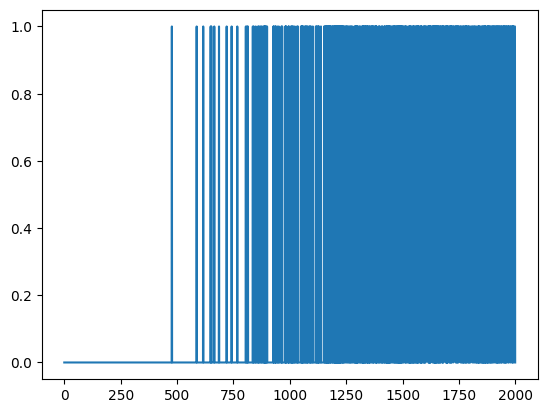

In [ ]:
plt.plot(rList)  # Crée un graphique linéaire pour visualiser l'évolution de la récompense totale au fil des épisodes d'entraînement.

It also begins to progress through the environment for longer than chance aroudn the 750 mark as well.

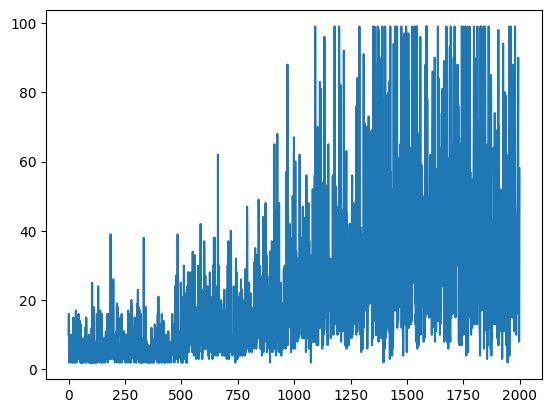

In [ ]:
plt.plot(jList) # Crée un graphique linéaire pour visualiser l'évolution du nombre d'étapes nécessaires par épisode au cours de l'entraînement.

## Analyse des résultats

###  Interprétation du Taux de Succès et des Graphiques

 **le taux de succès** est de  0.259% après 2000 parties.Ce taux indique clairement que, dans la grande majorité des parties (plus de 99.7%), l'agent n'atteint pas l'objectif du jeu FrozenLake où la récompense pour atteindre le but est de 1 et 0 sinon.

**L'analyse du premier graphique**, représentant l'évolution de la récompense totale par épisode, confirme cette observation. On constate que, durant les 250 premiers épisodes d'entraînement, la courbe reste quasi-constamment à zéro, indiquant que l'agent ne reçoit quasiment jamais de récompense positive (récompense de 1 pour atteindre le but).  Dans la tranche des épisodes 250 à 500, on observe l'apparition d'un petit groupe de faibles pics autour de l'épisode 400. À partir de l'épisode 500, et plus nettement après l'épisode 750, on observe l'apparition de quelques pics plus marqués de récompense à 1, signalant que l'agent parvient, de temps en temps , à atteindre le but.  Ces pics deviennent nettement plus fréquents dans la tranche des épisodes 1000 à 1250, dans la tranche de 1250 à 2000 on remarque qu'à chaque épisode il atteint pratiquemment tout le temps le but avec une immense majorité de pics bleues.Ce graphique illustre donc un apprentissage extrêmement lent et difficile, où l'agent peine à progresser de manière constante vers la réussite,surtout dans la première moitié de l'entraînement (jusqu'à l'épisode 1250 environs)

**L'analyse du second graphique**, représentant l'évolution du nombre d'étapes par épisode.Durant les 250 premiers épisodes, On constante que, durant les  250 épisodes d'entraînement,La courbe est  basse, avec des  pics faibles et rares. Ça montre que, au début, l'agent fait des épisodes très courts, avec peu d'actions (souvent moins de 20, et souvent même moins de 10), et qu'il ne varie pas beaucoup son comportement d'un épisode à l'autre.  Il ne fait pas beaucoup d'efforts pour aller loin dans l'environnement.

Dans la tranche des épisodes 250 à 500, on observe que la courbe commence à monter légèrement,  avec des pics un peu plus hauts et un peu plus nombreux.  Ça montre que l'agent commence à essayer d'aller un peu plus loin dans l'environnement, et qu'il varie un peu plus son comportement, mais il reste encore principalement sur des épisodes courts et peu exploratoires.

Dans la tranche des épisodes 500 à 750, on observe que la courbe  continue à monter, avec des pics nettement plus hauts et plus nombreux.Ça confirme la tendance à l'amélioration de la tranche précédente (250-500), avec une accélération de l'apprentissage et une plus grande instabilité du comportement de l'agent (plus d'oscillations).

Dans la tranche des épisode 750 à 1000 on observe que la courbe est nettement plus haute, avec des pics beaucoup plus hauts et beaucoup plus nombreux.On a une accélération encore plus forte de l'apprentissage et une grande variation  mais de plus en plus centrée sur des épisodes plus longs.

Dans la tranche des épisode 1000 à 1250 on observe que la courbe est toujours très haute,avec des pics toujours très hauts et très nombreux. Ça montre que l'agent atteint un plateau de performance relativement élevé, avec des épisodes souvent très longs et beaucoup de succès, mais que l'apprentissage ne progresse plus beaucoup, et que le comportement reste encore assez variable et instable, même si un peu moins que dans la tranche précédente.

Dans la tranche des épisode 1250 à 2000 on observe que la courbe est très haute avec des  pics très hauts et très nombreux.Ça montre clairement que l'agent a atteint un plateau de performance très élevé, avec des épisodes très souvent très longs et beaucoup de succès, et avec un comportement beaucoup plus stable et consistant qu'au début.



### Évaluation de la Performance de l'Agent

En résumé, l'analyse des résultats révèle une performance globale de l'agent très faible . Le taux de succès extrêmement bas (0.259%) montre une incapacité de l'agent à apprendre une stratégie fiable pour explorer l'environnement FrozenLake et atteindre le but . L'analyse des graphiques confirme un apprentissage lent, instable et peu efficace, caractérisé par une longue phase au début de son apprentissage sans progrès notable, puis une phrase d'améliorations et d'une forte variabilité des résultats.

Même si ces résultats sont décevants en termes de performance , L'agent apprend quand même, même si le résultat est faible. L'apparition de pics de récompense à 1 après l'épisode 750, et l'évolution du nombre d'étapes par épisode, montrent que le réseau neuronal commence à ajuster ses poids et à explorer des stratégies même si elles sont loin d'être optimales, lui permettent occasionnellement d'atteindre le but. Globalement, la performance de l'agent est en courageante,cela montre que le score peut-être encore largement améliorer.



### Hypothèses et Pistes d'Amélioration

Pour comprendre pourquoi l'agent n'obtient pas un score plus élevé, on peut formuler plusieurs hypothèses sur ces capacités d'apprentissage et identifier des pistes d'amélioration.

**Hypothèse 1 : Exploration de l'environnement**

la première hypothèse serait que l'agent n'explore pas suffisamment son environnement.

Au début de l'apprentissage, il est important que l'agent explore teste différentes actions et différents chemins pour découvrir les zones sûres (cases 'F') et le but ('G'), et éviter les trous ('H'). Si l'exploration est insuffisante, l'agent risque de se contenter de stratégies sous-optimales et de ne pas trouver le chemin le plus efficace vers le but.

**Amélioration possible:** Pour améliorer l'exploration, on pourrait augmenter la quantité de 'bruit' aléatoire ajouté lors du choix des actions, surtout au début de l'entraînement.

**Hypothèse 2 : les paramètres d'apprentissage**

Une autre hypothèse concerne les paramètres d'apprentissage de l'algorithme, et en particulier le taux d'apprentissage (learning_rate) et le facteur d'escompte (y ou gamma). Le taux d'apprentissage contrôle la vitesse à laquelle le réseau neuronal met à jour ses estimations des valeurs Q. Un taux d'apprentissage trop élevé pourrait rendre l'apprentissage instable  empêchant le réseau de converger vers des valeurs Q précises. À l'inverse, un taux d'apprentissage trop faible pourrait ralentir excessivement l'apprentissage, nécessitant un nombre d'épisodes d'entraînement beaucoup plus important pour obtenir des résultats significatifs. La valeur actuelle de learning_rate = 0.1 pourrait ne pas être optimale pour cet environnement et ce réseau neuronal.

Le facteur d'escompte détermine l'importance que l'agent accorde aux récompenses futures par rapport aux récompenses immédiates. Une valeur de y = 0.95, comme celle utilisée dans le code, signifie que l'agent valorise fortement les récompenses futures. Cependant, il est possible que pour l'environnement FrozenLake, une valeur de facteur d'escompte différente, peut-être plus faible, soit plus appropriée. Par exemple, si l'agent est trop 'patient' (gamma trop élevé), il pourrait mettre trop de temps à apprendre, ou privilégier des stratégies plus prudentes. À l'inverse, un facteur d'escompte trop faible pourrait rendre l'agent la vision de l'agent à court-therme et moins sensible à l'objectif à long terme d'atteindre la case 'G'.

**Amélioration possible:** Pour voir si le taux d'apprentissage et le facteur d'escompte ont un impact sur la valeur du score moyen de l'agent, il faudrait tester avec différentes valeurs pour le taux d'apprentissage et le facteur d'escompte et ainsi voir si cela à une influence sur le score moyen de l'agent.

**Hypothèse 3 : Nombre d'épisodes**

Une troisième hypothèse est que le nombre d'épisodes d'entraînement (2000) pourrait être insuffisant.

L'apprentissage par renforcement avec un réseau neuronal est souvent plus lent et plus gourmand en données que le Q-learning tabulaire. 2000 épisodes pourraient ne pas être suffisants pour permettre au réseau neuronal de converger vers une stratégie efficace dans l'environnement FrozenLake.

**Amélioration possible:** Pour vérifier cette hypothèse, on pourrait augmenter le nombre d'épisodes d'entraînement (par exemple, 5000, 10000 ou plus) et voir si le score moyen de l'agent s'améliore.
